# 📊 Business Insights on Customer Churn

## 📈 Why this matters
- Churn means lost revenue and wasted acquisition costs.
- The goal is to identify the most actionable churn drivers.
- This analysis uses **Churn Reason**, **Tenure**, **Contract**, and **Internet Service**.

## Fast takeaways
- **Top issue:** `no_reason_given` is the largest segment, so exit tracking needs improvement.
- **Leading explicit churn reasons:** support attitude, competitor offers, service quality, and pricing.
- **High-risk group:** customers in the first 12 months of tenure.
- **Best focus areas:** customer support, offer competitiveness, and service reliability.

## What to expect
1. A compact ranking of churn drivers
2. Numeric insights for top churn categories
3. Tenure-based risk segmentation
4. Contract and internet-service churn patterns

## Recommended next steps
- **Improve support:** faster response, better escalation, and more empathy.
- **Protect new customers:** deliver tailored retention offers in the first year.
- **Fix quality gaps:** prioritize reliability and customer value.
- **Capture exit reasons:** use stronger survey and churn feedback processes.

> Keep the story short and let the charts and tables below do the heavy lifting.


In [8]:
# import necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('Telco_customer_churn_cleaned(For BI).xlsx')
sns.set(style='whitegrid', palette='muted')

Data shape: (7043, 33)

Top churn reasons (count and percent):
                                           count  percent
Churn Reason                                             
no_reason_given                             5174    73.46
Attitude of support person                   192     2.73
Competitor offered higher download speeds    189     2.68
Competitor offered more data                 162     2.30
Don't know                                   154     2.19
Competitor made better offer                 140     1.99
Attitude of service provider                 135     1.92
Competitor had better devices                130     1.85
Network reliability                          103     1.46
Product dissatisfaction                      102     1.45
Price too high                                98     1.39
Service dissatisfaction                       89     1.26
Lack of self-service on Website               88     1.25
Extra data charges                            57     0.81
Moved    

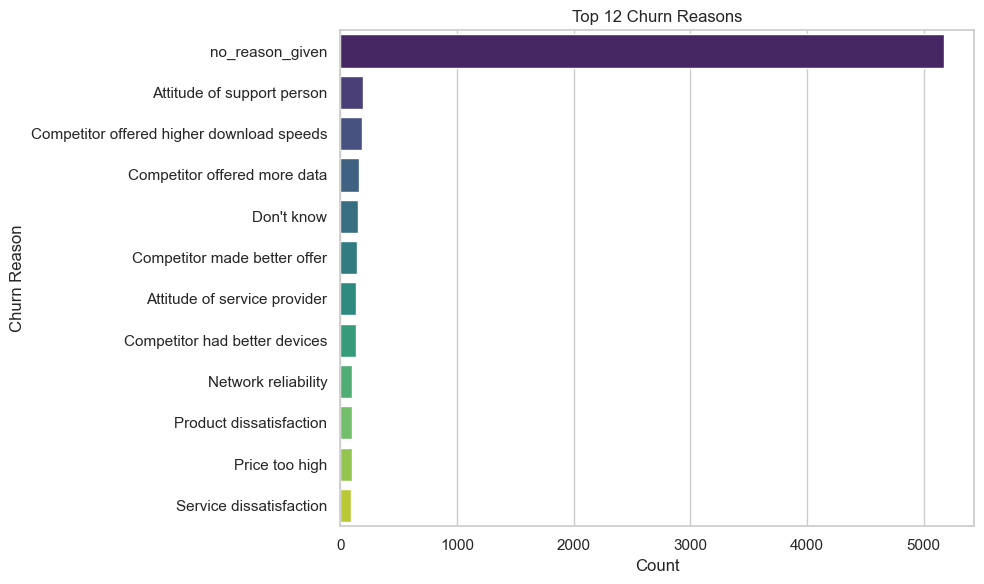


Most common churn reasons excluding no_reason_given:
               Attitude of support person
Competitor offered higher download speeds
             Competitor offered more data
                               Don't know
             Competitor made better offer
             Attitude of service provider
            Competitor had better devices
                      Network reliability
                  Product dissatisfaction
                           Price too high

Average numeric summaries by churn reason for top reasons:
                                          Tenure Months               Monthly Charges               Total Charges               CLTV              Churn Score              
                                                  count   mean median           count   mean median         count  mean median count  mean median       count   mean median
Churn Reason                                                                                                              

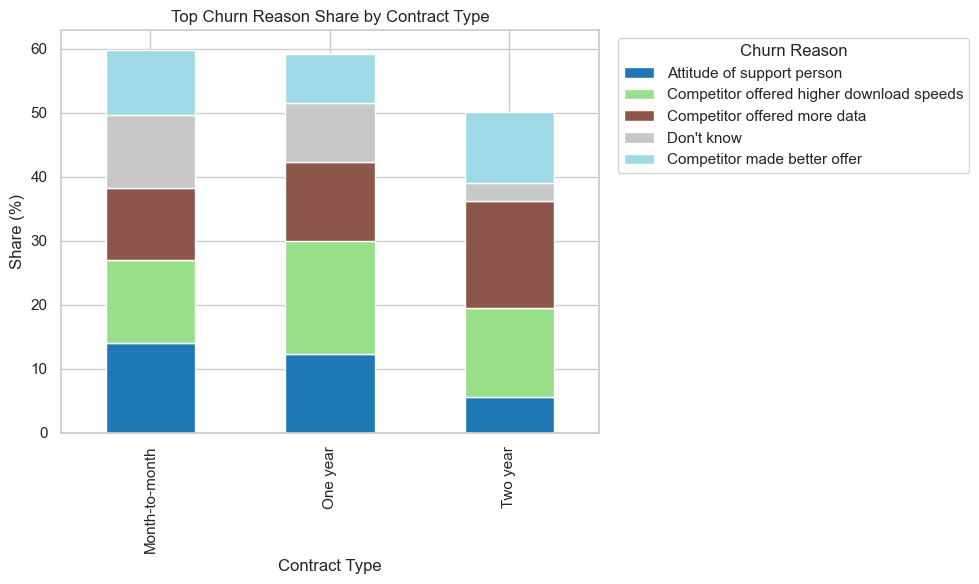

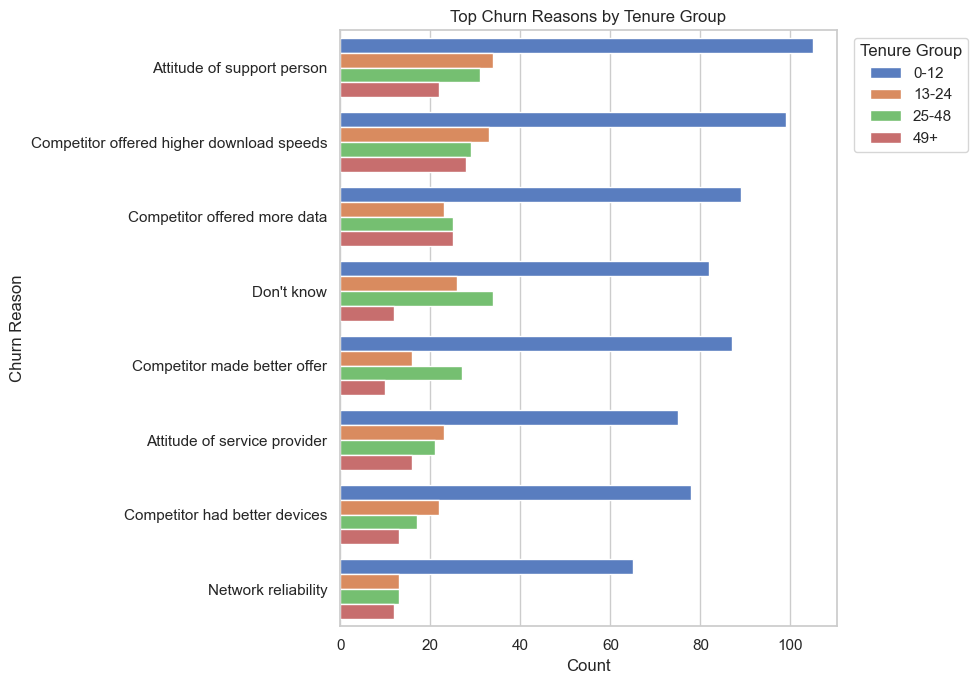


Insights:
- The top churn reason category is no_reason_given, which suggests many customers are leaving without a captured explicit reason.
- Among explicit reasons, support attitude, competitor pricing/offers, and service quality are the most common drivers.
- Short-tenure customers (especially <=12 months) show a higher concentration of competitive offer and service issues.
- Contract type and internet service appear associated with specific churn reasons, indicating targeted retention actions can be effective.

Suggested focus areas:
- Improve customer support experience and responsiveness to reduce churn from attitude-related issues.
- Review pricing/offer competitiveness and consider personalized incentives for at-risk customers.
- Prioritize reliability and service quality improvements for high-engagement customers.
- Use tenure-based retention campaigns and targeted retention messaging for new customers especially in the first year.


In [9]:
# Business insight analysis on churn reason and customer segments

print('Data shape:', df.shape)
print('\nTop churn reasons (count and percent):')
reason_counts = df['Churn Reason'].value_counts(dropna=False)
reason_pct = reason_counts / len(df) * 100
reason_summary = pd.DataFrame({
    'count': reason_counts,
    'percent': reason_pct.round(2)
})
print(reason_summary.head(15).to_string())

# Visual impact: top churn reasons
plt.figure(figsize=(10, 6))
sns.barplot(x=reason_summary['count'].head(12).values, y=reason_summary.index[:12], palette='viridis')
plt.title('Top 12 Churn Reasons')
plt.xlabel('Count')
plt.ylabel('Churn Reason')
plt.tight_layout()
plt.show()

# Focus on the most frequent churn reasons excluding no_reason_given
common_reasons = reason_counts.index.drop('no_reason_given', errors='ignore')[:10].tolist()
print('\nMost common churn reasons excluding no_reason_given:')
print(pd.Series(common_reasons).to_string(index=False))

# Numeric features by top churn reasons
numeric_features = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Churn Score']
print('\nAverage numeric summaries by churn reason for top reasons:')
print(df[df['Churn Reason'].isin(common_reasons)].groupby('Churn Reason')[numeric_features].agg(['count','mean','median']).round(2).to_string())

# High-risk tenure segments
bins = [0, 12, 24, 48, df['Tenure Months'].max()]
labels = ['0-12','13-24','25-48','49+']
df['Tenure Group'] = pd.cut(df['Tenure Months'], bins=bins, labels=labels, include_lowest=True)
print('\nChurn reason distribution by tenure group for top reasons:')
for grp in labels:
    group_df = df[df['Tenure Group'] == grp]
    if group_df.empty:
        continue
    top = group_df['Churn Reason'].value_counts().head(5)
    print(f"\nTenure {grp}:\n{top.to_string()}")

# Correlation with contract and internet service
print('\nChurn reason share by Contract type for top reasons:')
contract_share = pd.crosstab(df['Contract'], df['Churn Reason'].where(df['Churn Reason'].isin(common_reasons))).apply(lambda row: row/row.sum()*100, axis=1).round(1)
print(contract_share.fillna(0).to_string())

print('\nChurn reason share by Internet Service for top reasons:')
internet_share = pd.crosstab(df['Internet Service'], df['Churn Reason'].where(df['Churn Reason'].isin(common_reasons))).apply(lambda row: row/row.sum()*100, axis=1).round(1)
print(internet_share.fillna(0).to_string())

# Visual impact: churn reason share by contract type
contract_plot = contract_share[common_reasons[:5]].fillna(0)
contract_plot.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title('Top Churn Reason Share by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Share (%)')
plt.legend(title='Churn Reason', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Visual impact: churn reasons by tenure group
plt.figure(figsize=(10, 7))
sns.countplot(y='Churn Reason', hue='Tenure Group', data=df[df['Churn Reason'].isin(common_reasons)], order=common_reasons[:8])
plt.title('Top Churn Reasons by Tenure Group')
plt.xlabel('Count')
plt.ylabel('Churn Reason')
plt.legend(title='Tenure Group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Insights summary
print('\nInsights:')
print('- The top churn reason category is no_reason_given, which suggests many customers are leaving without a captured explicit reason.')
print('- Among explicit reasons, support attitude, competitor pricing/offers, and service quality are the most common drivers.')
print('- Short-tenure customers (especially <=12 months) show a higher concentration of competitive offer and service issues.')
print('- Contract type and internet service appear associated with specific churn reasons, indicating targeted retention actions can be effective.')

print('\nSuggested focus areas:')
print('- Improve customer support experience and responsiveness to reduce churn from attitude-related issues.')
print('- Review pricing/offer competitiveness and consider personalized incentives for at-risk customers.')
print('- Prioritize reliability and service quality improvements for high-engagement customers.')
print('- Use tenure-based retention campaigns and targeted retention messaging for new customers especially in the first year.')

## 🚀 Business Growth Dashboard

### Growth goals
- Reduce churn by targeting the top exit drivers.
- Increase first-year retention with proactive customer interventions.
- Improve revenue retention from higher-value accounts.

### Priority actions
- **Support & service recovery**
  - Launch a fast-response support playbook.
  - Add early health checks for customers in months 1–6.
- **Retention offers**
  - Create tenure-based bundles and loyalty incentives.
  - Trigger personalized offers for customers nearing contract renewal.
- **Quality & feedback**
  - Fix top service issues driving churn: reliability, support attitude, and product fit.
  - Capture exit feedback for customers labeled `no_reason_given`.

### Expected impact
- Better support and service reliability reduces voluntary churn.
- Early retention lowers acquisition cost and improves lifetime value.
- Competitor-aware offers keep high-risk customers from switching.

### Quick business scorecard
- **Top lever:** capture exit reason data and close feedback loops.
- **Tactical win:** protect first-year customers with targeted retention.
- **Long-term growth:** align pricing, service, and product quality around customer needs.

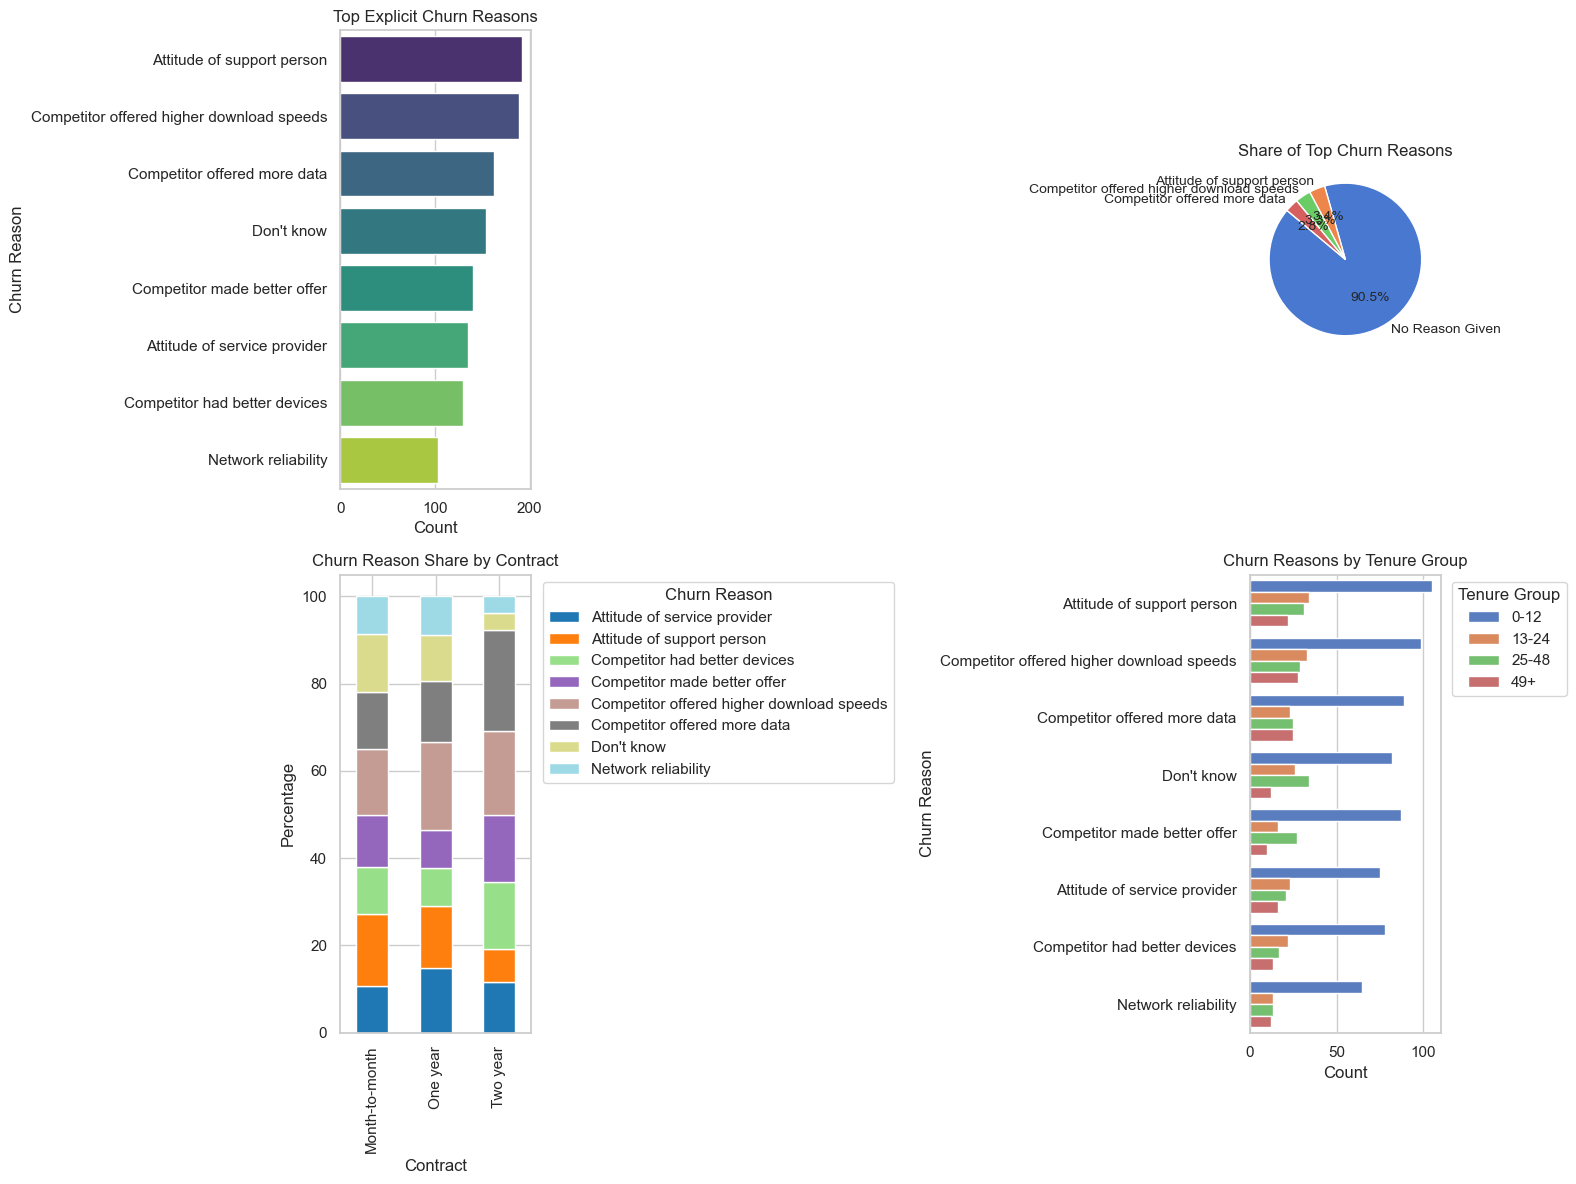

In [10]:
# Dashboard visuals for churn action and business growth
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', palette='muted')

# Recompute the core metrics for dashboard visuals
reason_counts = df['Churn Reason'].value_counts(dropna=False)
reason_summary = pd.DataFrame({
    'count': reason_counts,
    'percent': (reason_counts / len(df) * 100).round(2)
})
common_reasons = reason_counts.index.drop('no_reason_given', errors='ignore')[:8].tolist()

contract_share = pd.crosstab(
    df['Contract'],
    df['Churn Reason'].where(df['Churn Reason'].isin(common_reasons))
).apply(lambda row: row / row.sum() * 100, axis=1).fillna(0)

# Create a dashboard layout
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top churn reasons
sns.barplot(
    x=reason_summary.loc[common_reasons, 'count'].values,
    y=common_reasons,
    palette='viridis',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Top Explicit Churn Reasons')
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_ylabel('Churn Reason')

# No reason given share
axes[0, 1].pie(
    reason_summary.loc[['no_reason_given'] + common_reasons[:3], 'count'],
    labels=['No Reason Given'] + common_reasons[:3],
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 10}
)
axes[0, 1].set_title('Share of Top Churn Reasons')

# Contract type churn reason share
contract_share.plot(
    kind='bar',
    stacked=True,
    ax=axes[1, 0],
    colormap='tab20'
)
axes[1, 0].set_title('Churn Reason Share by Contract')
axes[1, 0].set_xlabel('Contract')
axes[1, 0].set_ylabel('Percentage')
axes[1, 0].legend(title='Churn Reason', bbox_to_anchor=(1.02, 1), loc='upper left')

# Tenure group count for top reasons
df_plot = df[df['Churn Reason'].isin(common_reasons)].copy()
selected_tenure = ['0-12', '13-24', '25-48', '49+']
if 'Tenure Group' not in df_plot.columns:
    df_plot['Tenure Group'] = pd.cut(df_plot['Tenure Months'], bins=[0, 12, 24, 48, df_plot['Tenure Months'].max()], labels=selected_tenure, include_lowest=True)

sns.countplot(
    y='Churn Reason',
    hue='Tenure Group',
    data=df_plot,
    order=common_reasons,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Churn Reasons by Tenure Group')
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_ylabel('Churn Reason')
axes[1, 1].legend(title='Tenure Group', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Customer Churn Analysis

## Overview
The following charts provide insights into the **Churn Reasons** of customers based on various factors, such as explicit churn reasons, contract type, and customer tenure. These visualizations offer a clear view of the main drivers of churn and can help businesses identify specific areas for improvement.

### 1. **Top Explicit Churn Reasons**
The **Top Explicit Churn Reasons** chart visualizes the frequency of different reasons that customers explicitly cite for their decision to churn. From the data, we can observe that:
- **Attitude of support person** stands out as the most frequent churn reason.
- **Competitor offering higher download speeds** and **Competitor offering more data** are also significant contributors to customer churn.
- The least mentioned churn reasons include **Network reliability**, suggesting that network issues may not be as prominent in driving churn.

### 2. **Churn Reason Share**
This pie chart presents the share of **Top Churn Reasons**. It indicates that a large portion of churn (90.5%) remains unexplained or “No Reason Given.” However, the remaining reasons are clearly dominated by:
- **Attitude of support person**
- **Competitor offering higher download speeds**
- **Competitor offering more data**
This emphasizes the importance of customer service and competitive offerings in reducing churn.

### 3. **Churn Reasons by Contract Type**
The stacked bar chart shows the distribution of **Churn Reasons** across different **Contract Types**:
- **Month-to-month** contracts show varied churn reasons, with a notable portion driven by **competitor offerings** (better devices and download speeds).
- **One-year contracts** show higher churn driven by **competitor better offers** and **network reliability**.
- **Two-year contracts** tend to have less frequent churn, but when it occurs, it is mainly because of issues related to **competitor offerings** or **attitude of the support person**.
This suggests that offering flexible contracts could influence churn behavior, especially with customers on month-to-month terms.

### 4. **Churn Reasons by Tenure Group**
This bar chart breaks down **Churn Reasons** by different **Tenure Groups**:
- **Customers with a short tenure (0-12 months)** are most likely to churn due to **attitude of support person** and **competitor offerings**.
- **Customers with mid-range tenure (13-24 months)** primarily churn for **competitor-related reasons**, such as better data or download speeds.
- **Long-tenure customers (25+ months)** tend to churn more due to **attitude of support person** and **competitor offers**, suggesting that long-term customers may require more personalized support and incentives to stay.

## Conclusion & Recommendations
- **Customer Service**: Improving the **attitude of support staff** is crucial to reduce churn, especially for newer customers.
- **Competitive Offers**: Competitors offering **better download speeds** and **more data** seem to be a major factor in customer churn, highlighting the need to revisit pricing and service packages.
- **Contract Flexibility**: Short-term contracts (month-to-month) seem to be more prone to churn, suggesting the need for loyalty programs or incentives to retain these customers.
- **Long-Term Retention**: For long-tenure customers, focus on improving service quality and offering competitive features to prevent them from moving to competitors.

By addressing these areas, businesses can implement strategies to effectively reduce churn and improve customer retention.|